In [1]:
# Linear Transformations


# What’s a Linear Transformation?

# Think of a 2D vector like an arrow on a piece of paper.
# A matrix can transform that vector — it can:
# Stretch it
# Shrink it
# Flip it
# Rotate it


# When we multiply a vector by a matrix, we're changing it in these ways.

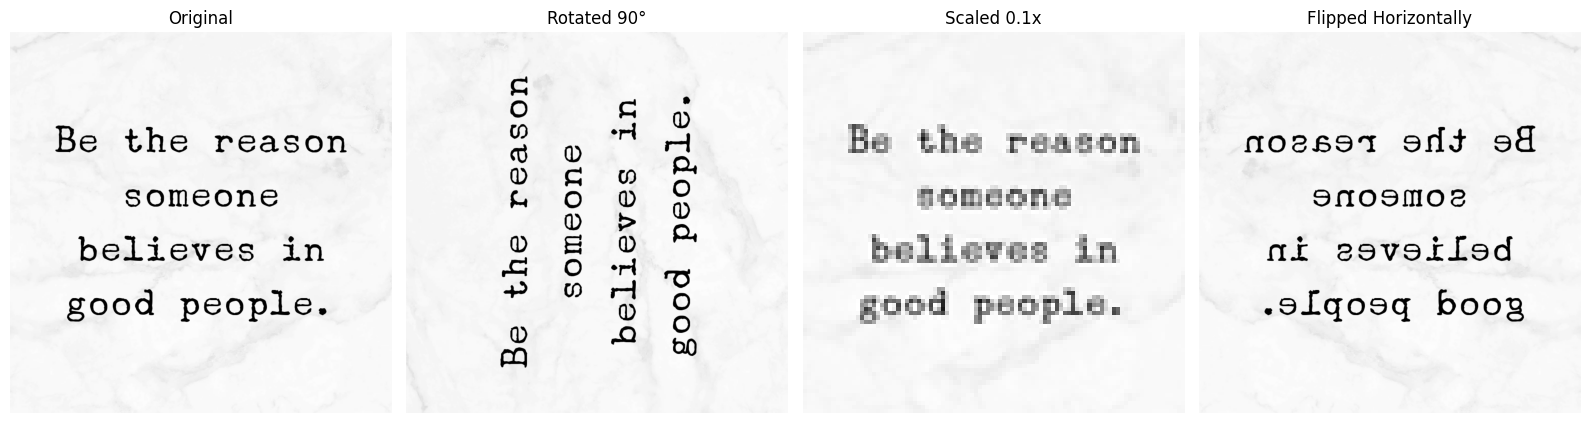

In [1]:
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# Load your image (adjust the path as needed)
img_path = 'image.webp'
original = Image.open(img_path)

# Apply transformations
rotated = original.rotate(90, expand=True)       # Rotate 90° counterclockwise
scaled = original.resize((int(original.width * 0.1), int(original.height *0.1)))  # Scale by 1.5x
flipped = ImageOps.mirror(original)              # Flip horizontally (mirror)

# Plot the images side by side
fig, axs = plt.subplots(1, 4, figsize=(16, 5))

titles = ["Original", "Rotated 90°", "Scaled 0.1x", "Flipped Horizontally"]
images = [original, rotated, scaled, flipped]

for ax, img, title in zip(axs, images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

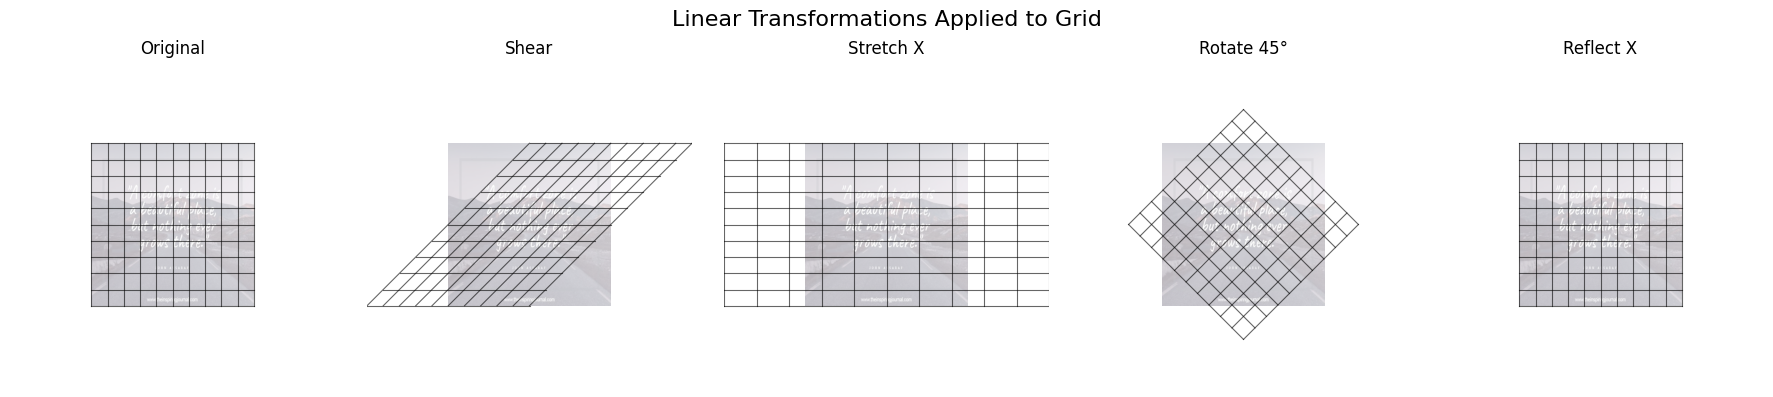

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load your image
img_path = "image4.jpeg" # path of image
image = Image.open(img_path)
img_width, img_height = image.size

# Function to draw grid
def draw_grid(ax, transform=np.eye(2), color='black'):
    # Create grid points
    lines = np.linspace(-1, 1, 11)
    for x in lines:
        pts = np.array([[x, -1], [x, 1]])
        pts_t = (transform @ pts.T).T
        ax.plot(pts_t[:, 0], pts_t[:, 1], color=color, lw=0.8, alpha=0.6)
    for y in lines:
        pts = np.array([[-1, y], [1, y]])
        pts_t = (transform @ pts.T).T
        ax.plot(pts_t[:, 0], pts_t[:, 1], color=color, lw=0.8, alpha=0.6)

# List of transformations
transforms = {
    "Original": np.eye(2),
    "Shear": np.array([[1, 1], [0, 1]]),
    "Stretch X": np.array([[2, 0], [0, 1]]),
    "Rotate 45°": np.array([
        [np.cos(np.pi / 4), -np.sin(np.pi / 4)],
        [np.sin(np.pi / 4),  np.cos(np.pi / 4)]
    ]),
    "Reflect X": np.array([[1, 0], [0, -1]])
}

# Plot setup
fig, axs = plt.subplots(1, len(transforms), figsize=(18, 4))

for ax, (name, matrix) in zip(axs, transforms.items()):
    ax.imshow(image, extent=[-1, 1, -1, 1], alpha=0.3)
    draw_grid(ax, transform=matrix)
    ax.set_title(name)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect('equal')
    ax.axis('off')

plt.tight_layout()
plt.suptitle("Linear Transformations Applied to Grid", fontsize=16)
plt.subplots_adjust(top=0.85)
plt.show()

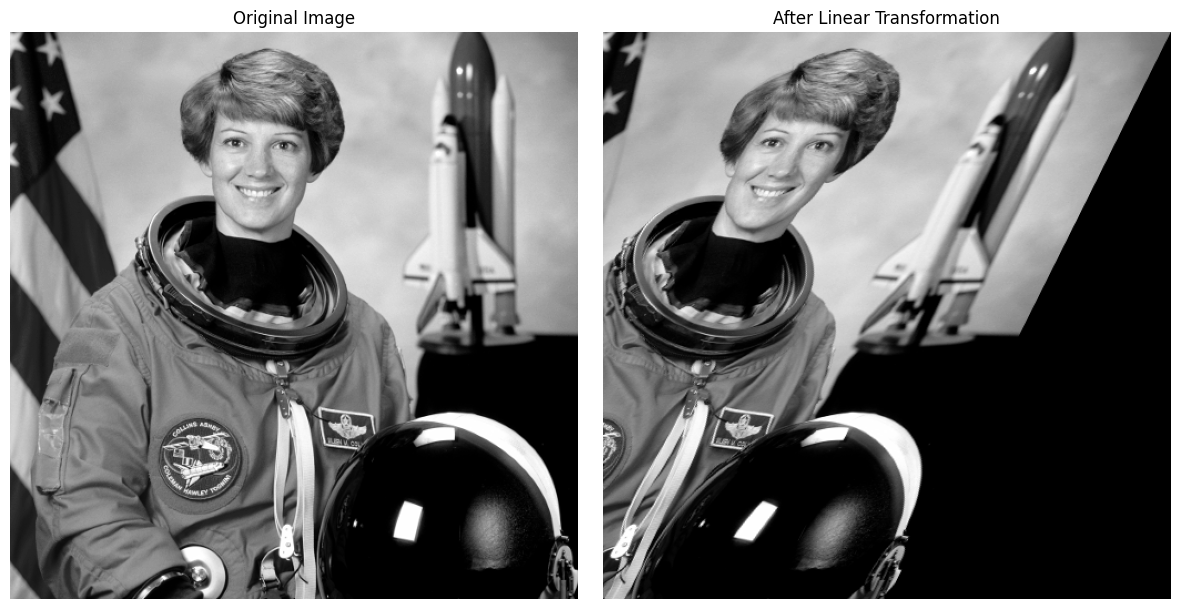

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import warp
from skimage.color import rgb2gray

# Loading a inbuilt image
image = rgb2gray(data.astronaut())# converting the RGB to grayscale

# Define a linear transformation matrix
# Example: Shear in x-direction
transform_matrix = np.array([
    [1, 0.5],
    [0, 1]
])

# Warp the image using the transformation matrix
def transform_coords(coords):
    return np.dot(coords, transform_matrix.T)

# Apply warp transformation -> Warp an image according to a given coordinate transformation.
warped_image = warp(image, transform_coords)

# Plot original and transformed image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(warped_image, cmap='gray')
axes[1].set_title('After Linear Transformation')
axes[1].axis('off')

plt.tight_layout()
plt.show()


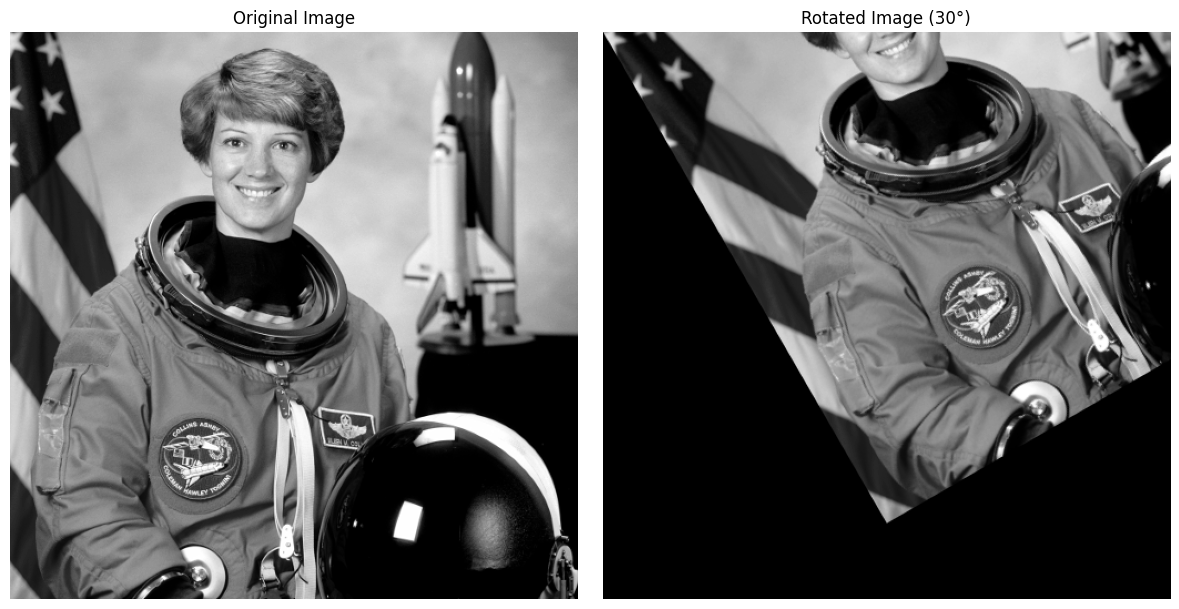

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import warp
from skimage.color import rgb2gray

# Similarly, we are takign the same astronaut images
image = rgb2gray(data.astronaut())

# Define rotation angle in degrees
theta = 30
theta_rad = np.deg2rad(theta)

# Define rotation matrix
A = np.array([
    [np.cos(theta_rad), -np.sin(theta_rad)],
    [np.sin(theta_rad),  np.cos(theta_rad)]
])

# Function to apply linear transformation to coordinates
def transform_coords(coords):
    return np.dot(coords, A.T)

# Apply warp transformation
rotated_image = warp(image, transform_coords)

# Plot original and rotated image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(rotated_image, cmap='gray')
axes[1].set_title(f'Rotated Image ({theta}°)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# Transformation -> multiplying a vector through a matrix
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[2, 0],
              [0, 1]])

v = np.array([[1], [1]])

print('A',A)
print('v',v)

#Matrix A multiplied by vector v
transformed_v = A @ v # same as np.matmul(A, v)

print('transformed_v',transformed_v)

print("Original vector:", v.ravel())
print("Transformed vector:", transformed_v.ravel())
#.ravel() is a function in NumPy that flattens an array — it turns it into a 1D array.

A [[2 0]
 [0 1]]
v [[1]
 [1]]
transformed_v [[2]
 [1]]
Original vector: [1 1]
Transformed vector: [2 1]


In [ ]:
# so we have
A = [2  0]
    [0  1]

v = [1]
    [1]

[2×1 + 0×1] = 2
[0×1 + 1×1] = 1


# The vector’s  x-component is doubled (from 1 to 2).
# The vector’s y-component remains unchanged (still 1).
# Because the stretching is not uniform in all directions, the resulting vector
# [2,1] no longer points in the same direction as [1,1].

# In other words, [1,1] is not an eigenvector of A.


SyntaxError: invalid syntax (4261267617.py, line 2)

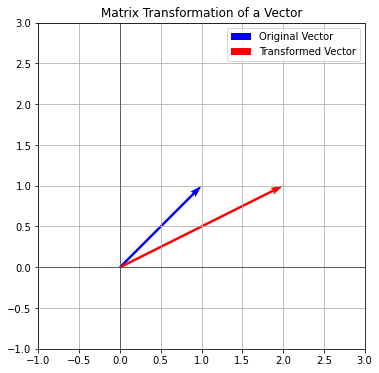

In [ ]:
# Plot the original and transformed vector
plt.figure(figsize=(6,6))
ax = plt.gca()

# Original vector in blue
ax.quiver(0, 0, v[0,0], v[1,0], angles='xy', scale_units='xy', scale=1, color='blue', label='Original Vector')

# Transformed vector in red
ax.quiver(0, 0, transformed_v[0,0], transformed_v[1,0], angles='xy', scale_units='xy', scale=1, color='red', label='Transformed Vector')

# Setup plot
ax.set_xlim(-1, 3)
ax.set_ylim(-1, 3)
ax.set_aspect('equal')
plt.grid()
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.legend()
plt.title('Matrix Transformation of a Vector')
plt.show()

# ax.quiver() in Matplotlib is used to create quiver plots,
# which visually represent vectors or flows by drawing arrows at specified points.
# The function takes several arguments to define the positions, directions,
# and appearance of the arrows.


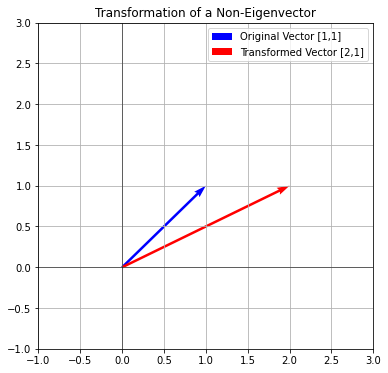

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Define the matrix and vector
# A = np.array([[2, 0],
#               [0, 1]])
# v = np.array([[1],
#               [1]])

# # Perform the transformation
# v_trans = A @ v

# # Create a plot to visualize the vectors
# plt.figure(figsize=(6,6))

# # Plot the original vector (in blue)
# plt.quiver(0, 0, v[0,0], v[1,0], angles='xy', scale_units='xy', scale=1, color='blue', label="Original Vector [1,1]")

# # Plot the transformed vector (in red)
# plt.quiver(0, 0, v_trans[0,0], v_trans[1,0], angles='xy', scale_units='xy', scale=1, color='red', label="Transformed Vector [2,1]")

# # Set the limits of the plot
# plt.xlim(-1, 3)
# plt.ylim(-1, 3)

# # Draw axis lines
# plt.axhline(0, color='black', linewidth=0.5)
# plt.axvline(0, color='black', linewidth=0.5)

# # Add grid, legend, and title
# plt.grid()
# plt.legend()
# plt.title('Transformation of a Non-Eigenvector')

# # Display the plot
# plt.show()


Eigenvectors are special: their direction doesn't change under the transformation

Eigenvalues are how much they're stretched/compressed

In [ ]:
# inbuilt function

A = np.array([[2, 1],
              [1, 2]])

eigvals, eigvecs = np.linalg.eig(A)

print("Eigenvalues:", eigvals)
print("Eigenvectors:\n", eigvecs)


Eigenvalues: [3. 1.]
Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


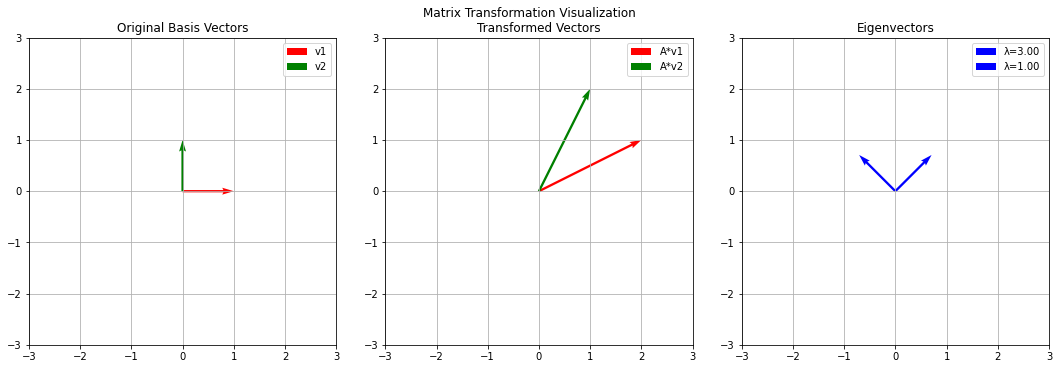

vecs [[1. 0.]
 [0. 1.]]
A [[2 1]
 [1 2]]
original [1. 0.]
original [0. 1.]
transformed [2. 1.]
transformed [1. 2.]
eigen vectors [0.70710678 0.70710678]
eigen vectors [-0.70710678  0.70710678]


In [ ]:
# For Visualizing Eigenvectors


# Standard basis vectors
vecs = np.eye(2)
colors = ['r', 'g']

# Create 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

titles = ["Original Basis Vectors", "Transformed Vectors", "Eigenvectors"]
for ax, title in zip(axes, titles):
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.grid(True)
    ax.set_title(title)

# Subplot 1: Original basis vectors
for i in range(2):
    v = vecs[:, i]
    axes[0].quiver(0, 0, v[0], v[1], color=colors[i], scale=1, scale_units='xy', angles='xy', label=f'v{i+1}')
axes[0].legend()

# Subplot 2: Transformed basis vectors
for i in range(2):
    v = vecs[:, i]
    t = A @ v
    axes[1].quiver(0, 0, t[0], t[1], color=colors[i], scale=1, scale_units='xy', angles='xy', label=f'A*v{i+1}')
axes[1].legend()

# Subplot 3: Eigenvectors
for i in range(len(eigvals)):
    v1 = eigvecs[:, i]
    axes[2].quiver(0, 0, v1[0], v1[1], color='b', scale=1, scale_units='xy', angles='xy',
                   label=f'λ={eigvals[i]:.2f}')
axes[2].legend()

plt.suptitle("Matrix Transformation Visualization")
plt.tight_layout()
plt.show()

print('vecs',vecs)

print('A',A)


for i in range(2):
    v = vecs[:, i]
    print('original',v)
for i in range(2):
    v = vecs[:, i]
    t = A @ v
    print('transformed',t)

for i in range(len(eigvals)):
    v = eigvecs[:, i]
    print('eigen vectors',v)



# The standard vectors go off in new directions when transformed.
# The eigenvectors point along 45° and -45° (they don't rotate under A).

In [ ]:
# sample problem

In [ ]:
Imagine a flat flag on a pole blowing in the wind.
The wind applies force in a consistent direction — say diagonally across the flag.
Let’s model the stretching effect of the wind as a linear transformation
represented by a matrix:
A = [3 1
    1 3]

This matrix transforms any 2D vector (a point on the flag) by stretching
and rotating it in space.


When we apply this transformation to most vectors (points on the flag),
they get stretched and rotated.

But there are two special directions (eigenvectors) where the vectors only
get stretched, not rotated.  Those directions are the eigenvectors.

And the stretch factor in each direction is the corresponding eigenvalue.


import numpy as np

A = np.array([[3, 1],
              [1, 3]])

eigvals, eigvecs = np.linalg.eig(A)

print("Eigenvalues:", eigvals)
print("Eigenvectors:\n", eigvecs)


In [ ]:
Eigenvalue - > 4:
Associated eigenvector:
[0.707
0.707]

This is the direction of the wind: northeast (45° angle).
Vectors in this direction get stretched by a factor of 4.

Eigenvalue 2:
Associated eigenvector:
[-0.707
0.707]

This is perpendicular to the wind.
Vectors in this direction get stretched by a factor of 2 (less effect).


When the wind blows:
One thread gets stretched a lot (eigenvalue 4).
The other gets stretched a bit (eigenvalue 2).

No thread changes direction — just their length.

Eigenvectors give you the invariant directions of transformation,
and eigenvalues tell you how much they're scaled. In physical systems,
this helps explain stability, resonance, stress directions, and more.

# Eigenvectors keep their direction when a transformation (matrix) is applied. Only their length (magnitude) may change — not their angle.

# Normal Vectors:
    
When you apply a matrix to most vectors, they:
rotate
stretch/shrink
even flip sometimes

→ Direction changes


# Eigenvectors:
When you apply the matrix A to an eigenvector v, it becomes:
    
A⋅v=λ⋅v

That means:
    
The output is just a scaled version of the same vector.
It’s pointing exactly in the same (or opposite) direction.

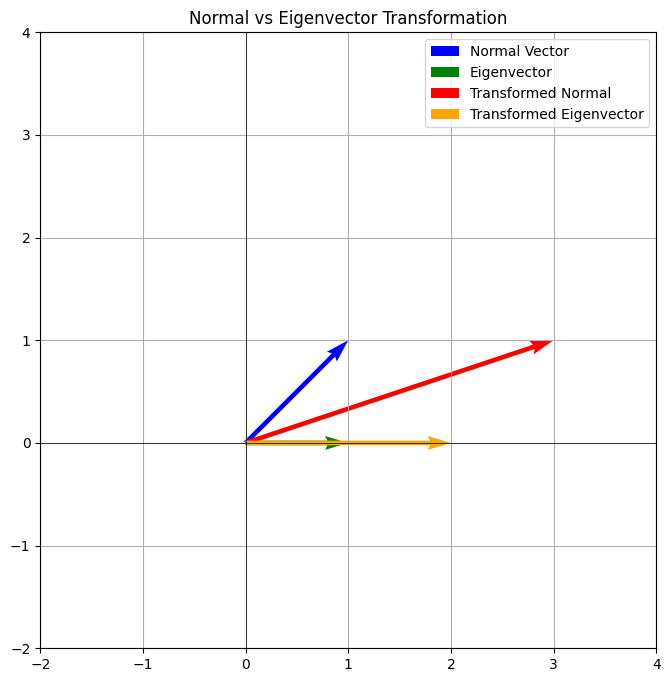

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define a linear transformation matrix (shear)
A = np.array([
    [2, 1],
    [0, 1]
])

# Arbitrary "normal" vector (not an eigenvector)
v_normal = np.array([1, 1])

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

# Pick the first eigenvector
v_eigen = eigenvectors[:, 0]

# Transform both vectors
v_normal_trans = A @ v_normal
v_eigen_trans = A @ v_eigen

# Plot original and transformed vectors
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the original vectors (blue/green)
ax.quiver(0, 0, v_normal[0], v_normal[1], angles='xy', scale_units='xy', scale=1, color='blue', label='Normal Vector')
ax.quiver(0, 0, v_eigen[0], v_eigen[1], angles='xy', scale_units='xy', scale=1, color='green', label='Eigenvector')

# Plot the transformed vectors (red/orange)
ax.quiver(0, 0, v_normal_trans[0], v_normal_trans[1], angles='xy', scale_units='xy', scale=1, color='red', label='Transformed Normal')
ax.quiver(0, 0, v_eigen_trans[0], v_eigen_trans[1], angles='xy', scale_units='xy', scale=1, color='orange', label='Transformed Eigenvector')

# Plot settings
ax.set_xlim(-2, 4)
ax.set_ylim(-2, 4)
ax.set_aspect('equal')
ax.grid(True)
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_title("Normal vs Eigenvector Transformation")
ax.legend()
plt.show()



Blue: original normal vector

Green: original eigenvector

Red: transformed normal vector (points somewhere else)

Orange: transformed eigenvector (stays in the same direction

v [1. 0.]
v [-1.00000000e+00  2.22044605e-16]


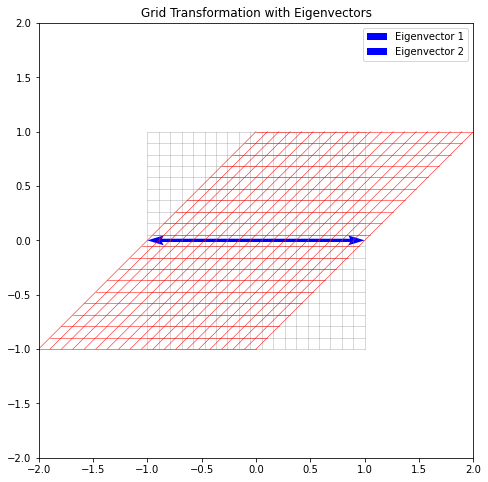

In [ ]:
# Shear Transformation

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load image
img_path = "image4.jpeg"
image = Image.open(img_path)

# Matrix A (a simple shear transformation)
A = np.array([[1, 1],
              [0, 1]])

# Eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(A)

# Grid setup
grid_range = np.linspace(-1, 1, 20)
grid_points = np.array([[x, y] for x in grid_range for y in grid_range])

# Apply transformation to grid points
transformed_points = np.dot(grid_points, A.T)

# Create figure
fig, ax = plt.subplots(figsize=(8, 8))

# Show image in background
# ax.imshow(image, extent=[-2, 2, -2, 2], alpha=0.5)

# Plot original grid
for x in grid_range:
    ax.plot([x]*len(grid_range), grid_range, color='gray', lw=0.5, alpha=0.6)
for y in grid_range:
    ax.plot(grid_range, [y]*len(grid_range), color='gray', lw=0.5, alpha=0.6)

# Plot transformed grid
for x in grid_range:
    line = np.array([[x, y] for y in grid_range])
    transformed_line = A @ line.T
    ax.plot(transformed_line[0], transformed_line[1], color='red', lw=0.5)

for y in grid_range:
    line = np.array([[x, y] for x in grid_range])
    transformed_line = A @ line.T
    ax.plot(transformed_line[0], transformed_line[1], color='red', lw=0.5)

# Plot eigenvectors
origin = np.array([0, 0])
for i in range(2):
    v = eigvecs[:, i]
    print('v',v)
    ax.quiver(*origin, *v, color='blue', scale=1, scale_units='xy', angles='xy', label=f"Eigenvector {i+1}")

ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.grid(False)
ax.legend()
plt.title("Grid Transformation with Eigenvectors")
plt.show()

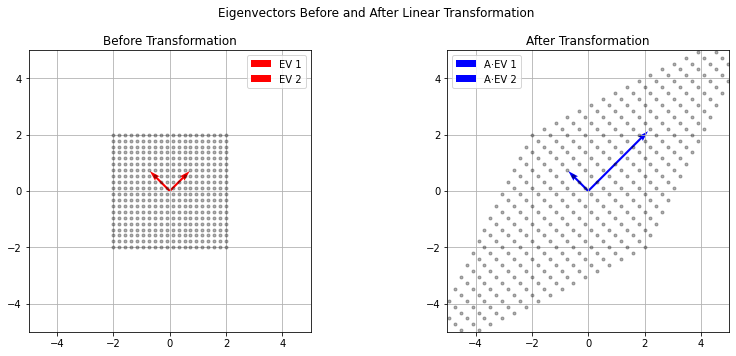

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define transformation matrix
A = np.array([[2, 1],
              [1, 2]])

# Compute eigenvalues and eigenvectors
eigvals, eigvecs = np.linalg.eig(A)

# Grid setup
grid_range = np.linspace(-2, 2, 20)
X, Y = np.meshgrid(grid_range, grid_range)
points = np.vstack([X.ravel(), Y.ravel()])

# Transform the grid points
transformed_points = A @ points

# Plotting
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
titles = ["Before Transformation", "After Transformation"]

for i, ax in enumerate(axs):
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.grid(True)
    ax.set_title(titles[i])

# Plot original grid and eigenvectors
axs[0].plot(points[0], points[1], 'k.', alpha=0.3)
for i in range(len(eigvals)):
    vec = eigvecs[:, i]
    axs[0].quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy',
                  scale=1, color='r', label=f"EV {i+1}")

# Plot transformed grid and transformed eigenvectors
axs[1].plot(transformed_points[0], transformed_points[1], 'k.', alpha=0.3)
for i in range(len(eigvals)):
    vec = eigvecs[:, i]
    tvec = A @ vec
    axs[1].quiver(0, 0, tvec[0], tvec[1], angles='xy', scale_units='xy',
                  scale=1, color='b', label=f"A·EV {i+1}")

axs[0].legend()
axs[1].legend()

plt.suptitle("Eigenvectors Before and After Linear Transformation")
plt.tight_layout()
plt.show()


# Are Eigen Values linearly Independent ?

In [ ]:
Key Rule
	Eigenvectors corresponding to distinct eigenvalues → Always linearly independent 
	Eigenvectors corresponding to the same eigenvalue → May or may not be independent 

Why?
Case 1: Different eigenvalues
If
Av1=λ1v1, Av2=λ2v2, λ1≠λ2

Then:
 These eigenvectors must point in different directions
 So they are linearly independent
________________________________________
Case 2: Same eigenvalue
If multiple eigenvectors share the same eigenvalue:
Av=λv

You can have:
	Independent vectors (good case) 
	Or 
    fewer independent ones than expected (bad case) 

Example 

Matrix:
A = [1 1 
     0 1]
	Eigenvalue = 1 (repeated) 
	But only one independent eigenvector 
So eigenvectors here are linearly dependent

Intuition
	Eigenvectors = special directions 
	But: 
	If directions are distinct (different eigenvalues) → independent 
	If they overlap (same eigenvalue) → may collapse into fewer directions


In [ ]:
| Aspect                           | Basis Vectors                                                          | Eigenvectors                                                                           |
| -------------------------------- | ---------------------------------------------------------------------- | -------------------------------------------------------------------------------------- |
| **Definition**                   | A set of vectors that span a vector space and are linearly independent | Vectors that only scale (not change direction) when a linear transformation is applied |
| **Purpose**                      | Used to represent any vector in a space                                | Used to understand how a transformation acts on vectors                                |
| **Dependence on Transformation** | Independent of any transformation                                      | Defined *with respect to a specific matrix/transformation*                             |
| **Direction Change**             | Can change direction under transformation                              | Direction remains the same (only magnitude changes)                                    |
| **Mathematical Condition**       | No specific equation (just linear independence & spanning)             | Satisfy: ( A\mathbf{v} = \lambda \mathbf{v} )                                          |
| **Uniqueness**                   | Many possible bases for a space                                        | Depends on the matrix; not arbitrary                                                   |
| **Number of Vectors**            | Equal to the dimension of the space                                    | Can be ≤ dimension (depends on matrix)                                                 |
| **Example (2D)**                 | ([1,0], [0,1]) (standard basis)                                        | Depends on matrix; e.g., for a scaling matrix, axes may be eigenvectors                |
| **Geometric Meaning**            | Defines coordinate system                                              | Defines invariant directions of transformation                                         |
| **Relation Between Them**        | Basis vectors can be chosen arbitrarily                                | Eigenvectors can *form a basis* if enough independent ones exist                       |


# Is parallel vector linearly dependent ?

In [ ]:
Two vectors are parallel if one is just a scalar multiple of the other:
v2=kv1

Consider the definition of linear dependence:
A set of vectors is linearly dependent if one vector can be written as a combination of others.
Here, that’s exactly what’s happening:
v2-kv1=0

So a non-trivial combination exists, which means they are dependent.

Intuition:
Parallel vectors lie on the same line, so they don’t add any “new direction” to the space.
(If one of the vectors is the zero vector, it is always linearly dependent with any vector)


In [1]:
import numpy as np

v1 = np.array([2, 4])
v2 = np.array([1, 2])   # parallel to v1 (v1 = 2 * v2)

# Stack vectors into matrix
A = np.column_stack((v1, v2))

# Check rank
rank = np.linalg.matrix_rank(A)

print("Matrix:\n", A)
print("Rank:", rank)

Matrix:
 [[2 1]
 [4 2]]
Rank: 1


# COMMON TABLE 

| Concept                                | Explanation (Formal)                                         | Intuition (For your Understanding)                      |
| -------------------------------------- | ------------------------------------------------------------ | ----------------------------------------------------- |
| **Scalar**                             | A single number                                              | Just a value (like weight, temperature)               |
| **Vector**                             | An ordered list of numbers                                   | A direction + magnitude (arrow in space)              |
| **Matrix**                             | A 2D array of numbers                                        | A transformation machine (input → output)             |
| **Vector Space**                       | Set of vectors closed under addition & scalar multiplication | A space where vectors “live” and behave nicely        |
| **Span**                               | All linear combinations of given vectors                     | All points you can reach using given vectors          |
| **Linear Independence**                | No vector can be written from others                         | Each vector adds a new direction                      |
| **Linear Dependence**                  | At least one vector depends on others                        | Redundant directions                                  |
| **Basis**                              | Minimal set of independent vectors that span space           | The “coordinate system” of the space                  |
| **Dimension**                          | Number of vectors in a basis                                 | Number of independent directions                      |
| **Dot Product**                        | v⋅w=∑viwi               | Measures alignment (angle similarity)                 |
| **Norm**                               | Length of a vector                                           | Size or magnitude                                     |
| **Orthogonality**                      | Dot product = 0                                              | Vectors are perpendicular                             |
| **Projection**                         | Shadow of one vector onto another                            | How much one vector lies in another direction         |
| **Matrix Multiplication**              | Combining linear transformations                             | Applying transformations step-by-step                 |
| **Identity Matrix**                    | Matrix that doesn’t change a vector                          | “Do nothing” transformation                           |
| **Inverse Matrix**                     | ( A^{-1} ) such that ( AA^{-1} = I )                         | Undoing a transformation                              |
| **Transpose**                          | Flipping rows ↔ columns                                      | Changing perspective (like reflection)                |
| **Determinant**                        | Scalar value from a square matrix                            | Scaling factor of transformation (area/volume change) |
| **Rank**                               | Number of independent rows/columns                           | Effective dimensionality of matrix                    |
| **Null Space**                         | Solutions to ( Ax = 0 )                             | Directions that collapse to zero                      |
| **Column Space**                       | Span of columns of matrix                                    | All possible outputs of transformation                |
| **Row Space**                          | Span of rows                                                 | Information content in equations                      |
| **Eigenvalues**                        | Scalars Scalars λin Av=λv                          | Amount of stretching             |
| **Eigenvectors**                       | Special vectors unchanged in direction                       | Natural directions of transformation                  |
| **Diagonalization**                    | Writing ( A = PDP^{-1} )                                     | Simplifying transformation into scaling               |
| **Trace**                              | Sum of diagonal elements                                     | Total scaling effect (roughly)                        |
| **System of Equations**                | Set of linear equations                                      | Intersection of lines/planes                          |
| **Gaussian Elimination**               | Row-reduction method                                         | Systematic solving process                            |
| **LU Decomposition**                   | Factorization ( A = LU )                                     | Breaking problem into simpler steps                   |
| **Singular Value Decomposition (SVD)** | A=UΣV^T                                        | Decomposing into rotations + scaling                  |
| **Orthogonal Matrix**                  | ( Q^T Q = I )                                                | Pure rotation/reflection (no scaling)                 |
| **Least Squares**                      | Best approximate solution                                    | Closest fit when exact solution doesn’t exist         |
| **Affine Transformation**              | Linear transform + translation                               | Move + stretch/rotate                                 |
| **Linear Transformation**              | Function preserving vector operations                        | Rule that moves vectors consistently                  |
